# Anharmonic Lattice Dynamics (ALD) for $\ce{Si}$ with [pheasy](https://gitlab.com/cplin/pheasy)

## Import Necessary Packages

In [1]:
import logging
import numpy as np
from kaldo.forceconstants import ForceConstants
from kaldo.phonons import Phonons
from kaldo.conductivity import Conductivity
import kaldo.controllers.plotter as plotter
import warnings
warnings.filterwarnings("ignore")
logging.getLogger("kaldo").setLevel(logging.WARNING)

## Load Force Constants Extracted by pheasy

In [2]:
# 'fc_pheasy' holds POSCAR, FORCE_CONSTANTS (2nd order) and
# FORCE_CONSTANTS_3RD (3rd order), all in pheasy's native text conventions
nrep = 3
supercell = np.array([nrep, nrep, nrep])

force_constants = ForceConstants.from_folder(
    folder="fc_pheasy",
    supercell=supercell,
    format="pheasy",
)

## Set Up the Phonon Object

In [3]:
k_points = 7
phonons_config = {
    "kpts": [k_points, k_points, k_points],
    "is_classic": False,
    "temperature": 300,
    "storage": "memory",
}

phonons = Phonons(forceconstants=force_constants, **phonons_config)

## Plot Phonon Dispersion Along a Standard Path

2026-07-12 21:31:36,965 - kaldo - WARNING - q-point [0.00735294 0.         0.00735294] is incommensurate with the supercell (3, 3, 3): the default dynamical-matrix construction can break symmetry-protected degeneracies (e.g. split transverse-acoustic branches). Consider is_unfolding=True.


/Users/juicy/miniconda3/envs/kaldo310/lib/python3.12/site-packages/seekpath/hpkot/__init__.py:172: DeprecationWarning: dict interface is deprecated. Use attribute interface instead
  conv_lattice = dataset["std_lattice"]


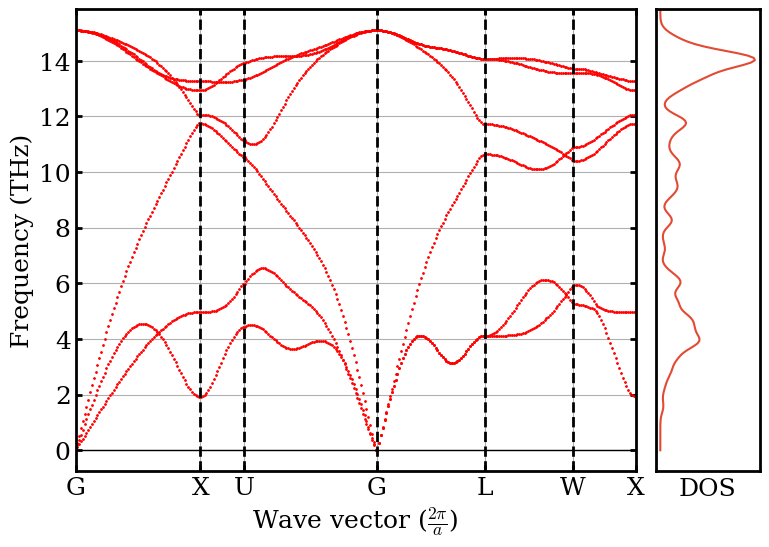

In [4]:
plotter.plot_dispersion(phonons, n_k_points=300, with_velocity=False, is_showing=True)

## Compute Thermal Conductivity

In [5]:
inv_cond_matrix = Conductivity(phonons=phonons, method="inverse").conductivity.sum(axis=0)
print("Bulk thermal conductivity, inverse (W/m/K): ",
      np.mean([inv_cond_matrix[0, 0], inv_cond_matrix[1, 1], inv_cond_matrix[2, 2]]))
print("\nThermal conductivity tensor (inverse):\n")
print(inv_cond_matrix)

Bulk thermal conductivity, inverse (W/m/K):  127.96685299804433

Thermal conductivity tensor (inverse):

[[128.10374684  60.39562922  60.28221936]
 [ 60.39281376 127.91578595  60.5681475 ]
 [ 60.26319861  60.55525588 127.8810262 ]]


In [6]:
rta_cond_matrix = Conductivity(phonons=phonons, method="rta").conductivity.sum(axis=0)
print("Bulk thermal conductivity, RTA (W/m/K): ",
      np.mean([rta_cond_matrix[0, 0], rta_cond_matrix[1, 1], rta_cond_matrix[2, 2]]))
print("\nThermal conductivity tensor (RTA):\n")
print(rta_cond_matrix)

2026-07-12 21:34:20,175 - kaldo - WARNING - rta method is specified, but n_iterations is not specified to be 0. Please check your setup. Now, n_iterations is reset to 0.


Bulk thermal conductivity, RTA (W/m/K):  123.42312326597767

Thermal conductivity tensor (RTA):

[[123.57027487  59.06467676  58.97291067]
 [ 59.06467676 123.33941214  59.24650531]
 [ 58.97291067  59.24650531 123.35968279]]
